This a correlation analysis of the key numerical features in the dataset related to tropical storms. The goal is to identify potential relationships between variables such as wind speed, pressure, damage, and other numerical features.

Loading the dataset csv into data frame and inspect the first few rows to understand its structure.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
dataset = pd.read_csv("completed_dataset_for_IS_project_25.csv")

print("From Dataset: Completed dataset")
print(dataset.head(10))

From Dataset: Completed dataset
   Year  MONTH  DAY   LAT  LONG  WIND_KTS  PRESSURE CAT  Shape_Leng Country  \
0  1880      8   11  23.0 -91.9        70         0  H1    0.806226  Mexico   
1  1880      8   11  23.4 -92.6        80         0  H1    0.761577  Mexico   
2  1880      8   11  23.7 -93.3        80         0  H1    0.583095  Mexico   
3  1880      8   12  24.0 -93.8        90         0  H2    0.670820  Mexico   
4  1880      9    6  23.9 -88.6        40         0  TS    0.360555  Mexico   
5  1880      8   10  22.0 -89.6        60         0  TS    0.854400  Mexico   
6  1880      8    9  21.0 -87.4        70         0  H1    0.761577  Mexico   
7  1880      8   10  21.3 -88.1        60         0  TS    0.854400  Mexico   
8  1880      8   10  21.6 -88.9        50         0  TS    0.806226  Mexico   
9  1880     10    6  21.4 -87.3        50         0  TS    0.800000  Mexico   

   ...   Mar   Apr  May   Jun   Jul   Aug   Sep   Oct   Nov   Dec  
0  ... -0.09 -0.17 -0.1 -0.21 

Before the analysis, we must check the basic summary statistics of the numerical columns to better understand the data distribution.

In [2]:
numeric_df = dataset.select_dtypes(include=['float64', 'int64'])

# Display basic statistics for numeric columns
numeric_df.describe()

,Year,MONTH,DAY,LAT,LONG,WIND_KTS,PRESSURE,Shape_Leng,CO2 emission (Tons),Jan,...,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
count,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,5.265600e+04,52656.000000,...,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000,52656.000000
mean,1963.141826,8.501937,15.890022,23.642867,-86.212449,54.021137,392.746069,1.194504,3.681439e+10,0.116301,...,0.146256,0.112056,0.100206,0.090699,0.102566,0.097883,0.099385,0.115567,0.109884,0.100033
std,35.909454,1.380465,8.802759,9.512564,36.878742,25.238544,485.291884,0.845690,8.179390e+10,0.359146,...,0.356719,0.318158,0.299611,0.307962,0.285277,0.294818,0.293778,0.302885,0.315836,0.331759
min,1880.000000,1.000000,1.000000,4.200000,-180.000000,10.000000,0.000000,0.000000,0.000000e+00,-0.810000,...,-0.630000,-0.580000,-0.550000,-0.520000,-0.510000,-0.550000,-0.580000,-0.580000,-0.550000,-0.820000
25%,1941.000000,8.000000,8.000000,16.200000,-110.700000,35.000000,0.000000,0.700000,6.906640e+06,-0.150000,...,-0.150000,-0.140000,-0.140000,-0.140000,-0.110000,-0.130000,-0.120000,-0.080000,-0.080000,-0.140000
50%,1972.000000,9.000000,16.000000,21.300000,-84.600000,45.000000,0.000000,1.004988,2.648858e+09,0.080000,...,0.100000,0.100000,0.110000,0.030000,0.040000,0.050000,0.060000,0.090000,0.050000,0.080000
75%,1992.000000,9.000000,23.000000,29.800000,-64.400000,70.000000,992.000000,1.421267,1.215048e+10,0.390000,...,0.470000,0.340000,0.330000,0.370000,0.330000,0.350000,0.340000,0.330000,0.300000,0.380000
max,2008.000000,12.000000,31.000000,69.000000,180.000000,165.000000,1024.000000,11.180340,3.530000e+11,1.020000,...,0.880000,0.770000,0.690000,0.770000,0.650000,0.710000,0.710000,0.750000,0.740000,0.790000


We'll now calculate the correlation matrix for the numeric columns in the dataset. This matrix will show pairwise correlation coefficients between different features.

In [4]:
# Calculate the correlation matrix
corr_matrix = numeric_df.corr()
corr_matrix


,Year,MONTH,DAY,LAT,LONG,WIND_KTS,PRESSURE,Shape_Leng,CO2 emission (Tons),Jan,...,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Year,1.000000,-0.131170,0.026196,-0.242001,-0.239545,-0.128157,0.656168,-0.094343,0.272332,0.806127,...,0.816274,0.824170,0.832666,0.836982,0.825111,0.822956,0.816117,0.794154,0.790563,0.793073
MONTH,-0.131170,1.000000,-0.200987,0.152080,0.204146,0.093366,-0.011618,0.058983,-0.095308,-0.077606,...,-0.083402,-0.080479,-0.077254,-0.074274,-0.079048,-0.071682,-0.069393,-0.063838,-0.059438,-0.074366
DAY,0.026196,-0.200987,1.000000,-0.008218,-0.041128,-0.008548,0.022403,-0.007179,0.018811,0.018729,...,0.027803,0.021470,0.023042,0.020124,0.022283,0.022275,0.014097,0.022843,0.017242,0.019957
LAT,-0.242001,0.152080,-0.008218,1.000000,0.428941,0.045653,0.002759,0.478333,0.074727,-0.160226,...,-0.161027,-0.158419,-0.166072,-0.156568,-0.151495,-0.147506,-0.153543,-0.138994,-0.130335,-0.148207
LONG,-0.239545,0.204146,-0.041128,0.428941,1.000000,0.098890,-0.020639,0.248866,-0.310212,-0.160859,...,-0.168215,-0.161798,-0.176217,-0.156021,-0.152227,-0.143996,-0.148993,-0.129721,-0.129353,-0.151873
WIND_KTS,-0.128157,0.093366,-0.008548,0.045653,0.098890,1.000000,-0.039197,0.052822,-0.103382,-0.090723,...,-0.102319,-0.100725,-0.100370,-0.092889,-0.094893,-0.095561,-0.100570,-0.103287,-0.106595,-0.105320
PRESSURE,0.656168,-0.011618,0.022403,0.002759,-0.020639,-0.039197,1.000000,-0.011782,0.212815,0.663077,...,0.720916,0.723108,0.697384,0.730061,0.730580,0.710366,0.693952,0.688928,0.680923,0.667776
Shape_Leng,-0.094343,0.058983,-0.007179,0.478333,0.248866,0.052822,-0.011782,1.000000,-0.013856,-0.066994,...,-0.067250,-0.059735,-0.066890,-0.055404,-0.057421,-0.055711,-0.057638,-0.056266,-0.054812,-0.059510
CO2 emission (Tons),0.272332,-0.095308,0.018811,0.074727,-0.310212,-0.103382,0.212815,-0.013856,1.000000,0.242791,...,0.253139,0.255664,0.255018,0.264702,0.246372,0.245150,0.258125,0.253118,0.252099,0.249407
Jan,0.806127,-0.077606,0.018729,-0.160226,-0.160859,-0.090723,0.663077,-0.066994,0.242791,1.000000,...,0.872350,0.891506,0.899473,0.861634,0.856603,0.857908,0.845816,0.818806,0.783473,0.766242


To better understand the relationships between the features, we will create a heatmap of the correlation matrix. This will visually show the strength of correlations between variables.

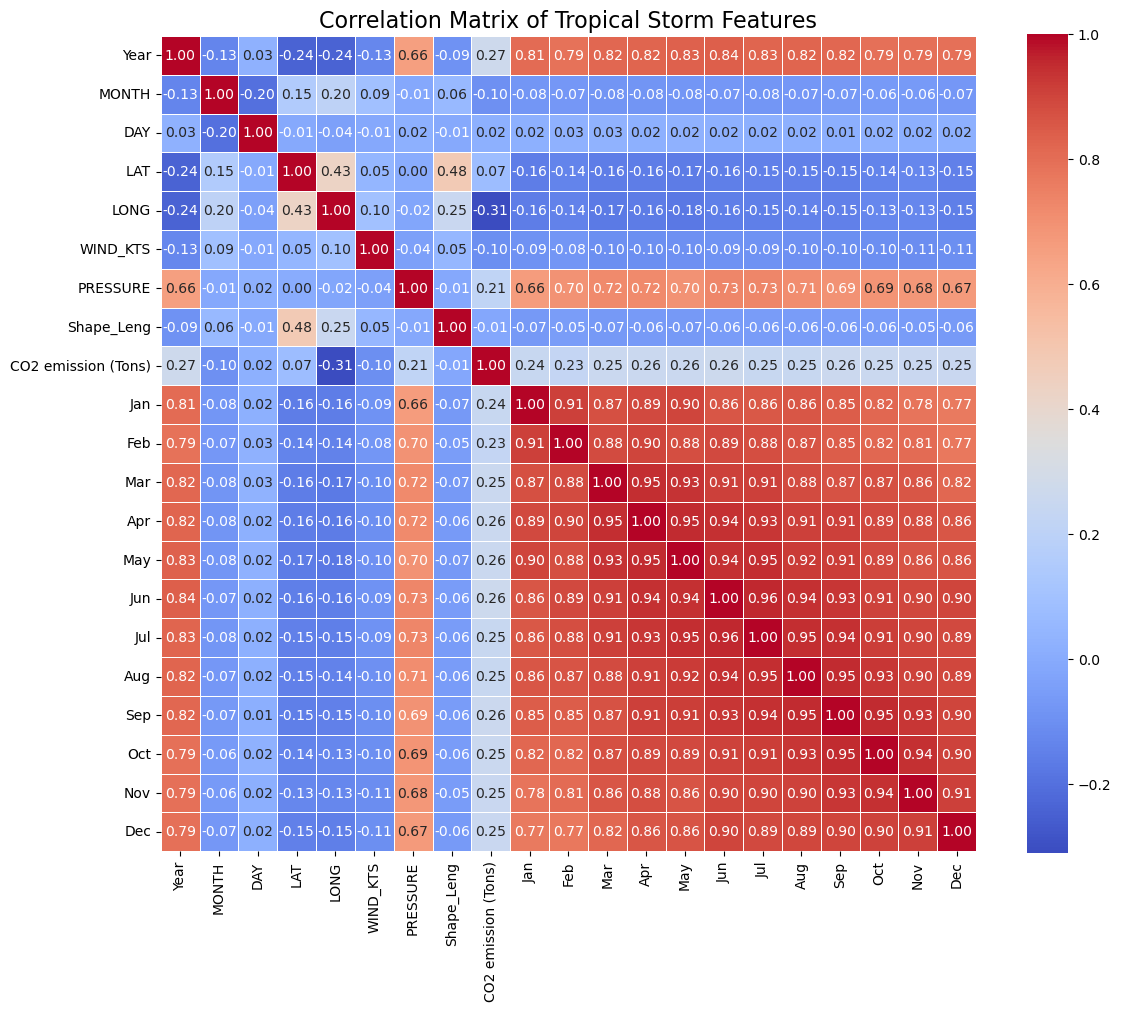

In [5]:
# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix of Tropical Storm Features", fontsize=16)
plt.tight_layout()

# Saving the heatmap as an image file
plt.savefig("correlation_matrix.png")

# Show the plot
plt.show()